### Identify the intersection between fetal-enriched and disease-enriched TFs

In [1]:
library(tidyverse)
library(scales)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




Load in the significant fetal and disease regulons (padj <0.05), filter to those that have postnatal N disease AUC > 0.05

In [2]:
fetal_res <- read.csv("04C_fetal_sig_regulon_df.csv")
fetal_res <- fetal_res %>%
  mutate(regulon = str_extract(regulon, "^[^_]+"))
fetal_res <- fetal_res %>% dplyr::filter(padj < 0.05) %>% dplyr::filter(AUC_mean_postnatal_N > 0.05)

disease_res <- read.csv("04C_disease_sig_regulon_df.csv")
disease_res <- disease_res %>%
  mutate(regulon = str_extract(regulon, "^[^_]+"))
disease_res <- disease_res %>% dplyr::filter(padj < 0.05) %>% dplyr::filter(AUC_mean_postnatal_N > 0.05)

In [3]:
fetal_df <- fetal_res %>%
  select(regulon, cell_type, log2FC_fetal = log2FC)

disease_df <- disease_res %>%
  select(regulon, cell_type, log2FC_disease = log2FC)

In [4]:
shared_regulons <- fetal_df %>%
  inner_join(disease_df, by = c("regulon", "cell_type"))

shared_regulons_dir <- shared_regulons %>%
  filter(sign(log2FC_fetal) == sign(log2FC_disease))

In [5]:
#shared_regulons_dir

In [6]:
sig_shared_regulons_dir <- shared_regulons_dir %>%
  filter(abs(log2FC_fetal) > 0.25, abs(log2FC_disease) > 0.1)

In [7]:
df_long <- sig_shared_regulons_dir %>%
  pivot_longer(
    cols = starts_with("log2FC_"),
    names_to = "comparison",
    names_prefix = "log2FC_",
    values_to = "log2FC"
  )

df_long %>% head()

regulon,cell_type,comparison,log2FC
<chr>,<chr>,<chr>,<dbl>
TCF4,Cardiomyocyte,fetal,0.6855273
TCF4,Cardiomyocyte,disease,0.1044070
BACH2,Cardiomyocyte,fetal,0.2668514
BACH2,Cardiomyocyte,disease,0.1298320
FREM1,Cardiomyocyte,fetal,0.4441674
FREM1,Cardiomyocyte,disease,0.1097699


In [8]:
unique(df_long$regulon)

[1] "TCF4"    "BACH2"   "FREM1"   "HEYL"    "EBF3"    "ZEB1"    "SMAD1"  
 [8] "THRB"    "CEBPD"   "ZNF704"  "KLF12"   "PRDM5"   "TEAD1"   "IRF8"   
[15] "SOX5"    "PDLIM5"  "NPAS2"   "MXI1"    "NFATC2"  "FOXN3"   "ZNF385D"

In [10]:
df_long$regulon <- factor(
  df_long$regulon,
  levels = rev(sort(unique(df_long$regulon)))
)

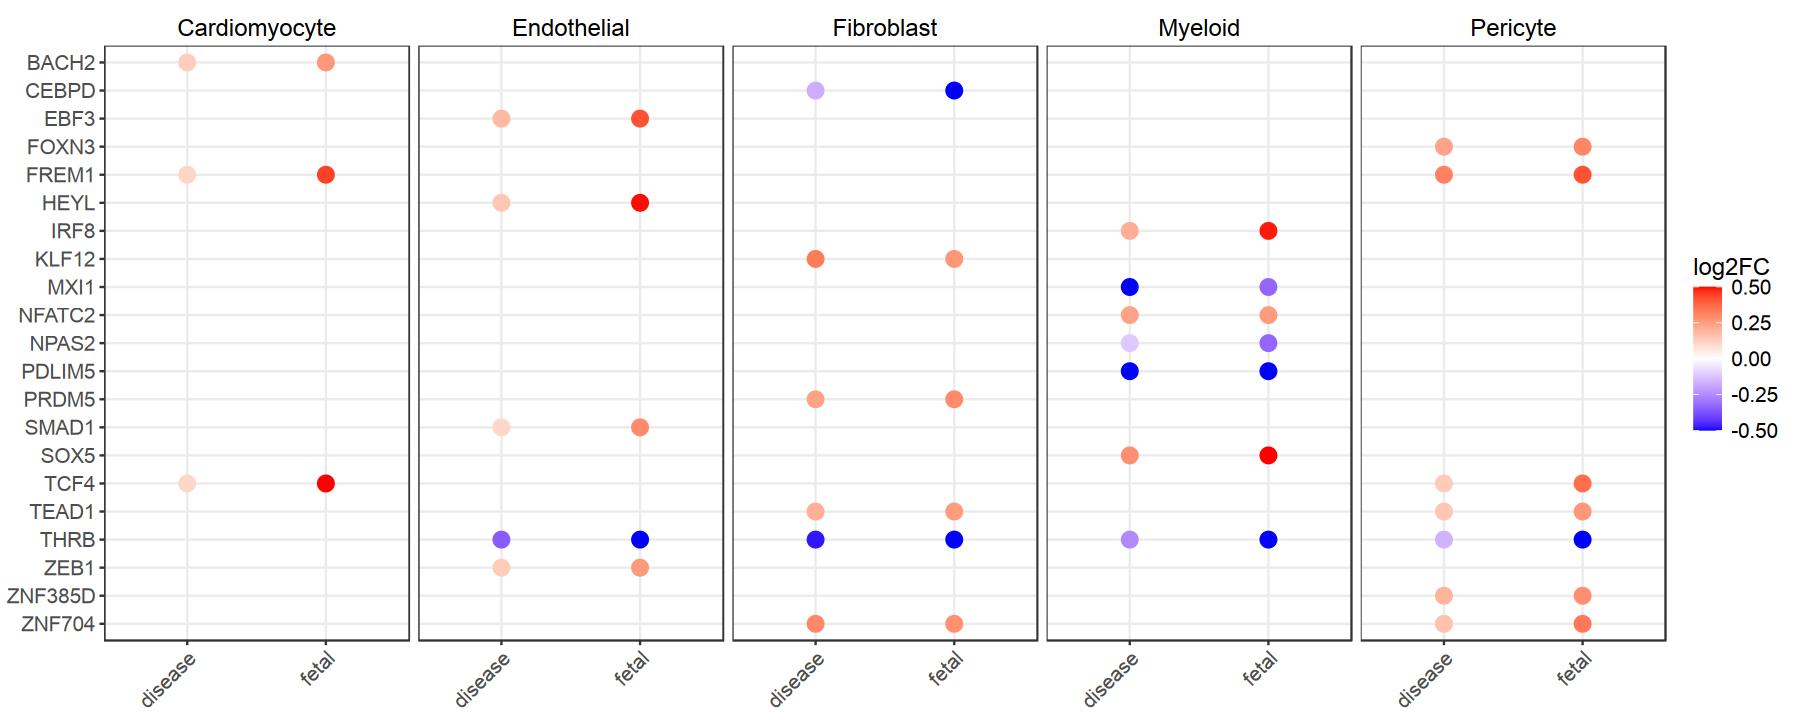

In [14]:
options(repr.plot.width = 15, repr.plot.height = 6)

p1 <- ggplot(data = df_long, aes(x = comparison, y = regulon, color = log2FC)) + 
    geom_point(size = 4) +
    facet_wrap(~ cell_type, ncol = 5) +  
    scale_color_gradient2(low = "blue", mid = "white", high = "red", midpoint = 0, limits = c(-0.5, 0.5), oob = squish) + 
    theme_bw() +
    theme(
        strip.background = element_blank(),  
        strip.text = element_text(size = 14, color = "black"),  # clean facet labels
        legend.text = element_text(size = 12),
        legend.title = element_text(size = 14),
        axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
        axis.text.y = element_text(size = 12),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        plot.title = element_text(size = 18, hjust = 0.5)
)

ggsave(p1, filename = "05_fetal_reactivation_TFs.pdf", width = 15, height = 6)

p1

In [15]:
write.csv(df_long, file = "05C_fetal_reactivation_TFs.csv")